## Qualtrics Data

In [821]:
import pandas as pd

exp_start_time = pd.to_datetime("2025-08-18 6:00:00")
exp_end_time = pd.to_datetime("2025-08-20 15:00:00")

# csv_path = "results/DPU+Explanations+-+Prolific+-+BetweenSubject+-+Pilot_11_8_2025.csv"
csv_path = "results/DPU+Explanations+-+Prolific+-+BetweenSubject_August+20.csv"
qualtrics_results = pd.read_csv(csv_path)

# Clean the data first - remove any rows where StartDate might be the header or invalid
qualtrics_results = qualtrics_results[qualtrics_results['StartDate'] != 'Start Date'].copy()  # Remove header rows if any
qualtrics_results = qualtrics_results.dropna(subset=['StartDate'])  # Remove rows with missing StartDate
print(f"df_cleaned first StartDate and ProlificID values:\n{qualtrics_results[['StartDate', 'ProlificID']].tail(3)}")

# Convert to datetime with error handling
try:
    qualtrics_results['StartDate'] = pd.to_datetime(qualtrics_results['StartDate'], errors='coerce')
    
    # Filter the data
    rellevant_qualtrics = qualtrics_results[
        (qualtrics_results['StartDate'] >= exp_start_time) & (qualtrics_results['StartDate'] <= exp_end_time) &
        (qualtrics_results['ProlificID'].astype(str).str.len() > 20) &
        (qualtrics_results['Finished'] == 'True')  # Ensure the survey was completed
        
    ]
    
    print(f"Cleaned data shape: {qualtrics_results.shape}")
    print(f"Filtered data shape: {rellevant_qualtrics.shape}")

except Exception as e:
    print(f"Error in datetime conversion: {e}")
    print("Let's examine the problematic values:")
    print(qualtrics_results['StartDate'].value_counts().head(10))

df_cleaned first StartDate and ProlificID values:
               StartDate                ProlificID
496  2025-08-20 03:25:28  5d1290103b20b0000102e8e3
497  2025-08-20 04:06:30  66a41543adadffb17baf40b8
498  2025-08-20 03:18:14  5e63f5da8a25da181c011cad
Cleaned data shape: (498, 104)
Filtered data shape: (284, 104)


In [822]:
#find a specific participant
rellevant_qualtrics[rellevant_qualtrics['prolific_id'] == '673153d88d13bed22065fd88']

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,AI_4,AI_5,comments,Q261,Random_ID,AWSURL,group,ProlificID,agent_level,bonus_group
479,2025-08-20 02:54:24,2025-08-20 03:38:58,IP Address,82.132.222.197,100,2673,True,2025-08-20 03:38:58,R_2c1xtW8WyrHV1SA,NaN,...,4. Neither agree nor disagree,5,"Very interesting study, thank you. In this cas...",NaN,2626664304,NaN,1,673153d88d13bed22065fd88,APPL3,2323


## DPU SQL Data

In [823]:

# import sys
# import os
# sys.path.append(os.getcwd())
from mysql_data_explorer import get_all_tables_from_mysql, alter_database_tables
import pandas as pd

all_tabels = get_all_tables_from_mysql()
print(all_tabels.keys())

✅ Connected to Azure MySQL database: mysql_dpu
📊 Found 5 tables: ['actions', 'feedback_actions', 'tutorial_actions', 'user_choices', 'users']
   ✅ Loaded 'actions': 0 rows, 11 columns
   ✅ Loaded 'feedback_actions': 3894 rows, 12 columns
   ✅ Loaded 'tutorial_actions': 15652 rows, 8 columns
   ✅ Loaded 'user_choices': 1235 rows, 16 columns
   ✅ Loaded 'users': 352 rows, 5 columns
🔌 Database connection closed
dict_keys(['actions', 'feedback_actions', 'tutorial_actions', 'user_choices', 'users'])


In [824]:
# Delete the existing new_agent_score column and create new_agent_score_list column
# alter_database_tables("ALTER TABLE user_choices DROP COLUMN old_agent_score;")
# alter_database_tables("ALTER TABLE user_choices ADD COLUMN old_agent_score_list TEXT;")


In [825]:
users_df = all_tabels['users']
users_df.tail(10)

,id,user_id,timestamp,simillarity_level,final_score
342,343,6691a5c500af8a7d634133f7,2025-08-20 09:18:19,NaN,11.5
343,344,5e9430cc1ed15800084ffbb0,2025-08-20 09:18:37,NaN,13.3
344,345,5c9d88bb2b3c77001744ec1c,2025-08-20 09:18:42,NaN,14.2
345,346,5bffc3ae4108380001f5cd63,2025-08-20 09:20:13,NaN,13.4
346,347,5c158ec0c6b01c0001bcfa72,2025-08-20 09:33:10,NaN,14.2
347,348,673153d88d13bed22065fd88,2025-08-20 09:37:16,NaN,13.4
348,349,66986ab71f2b54203f26ad32,2025-08-20 09:43:18,NaN,11.6
349,350,663791040de5898120ca93cd,2025-08-20 10:02:33,NaN,13.6
350,351,5d1290103b20b0000102e8e3,2025-08-20 10:06:56,NaN,12.9
351,352,1014,2025-08-24 09:00:49,4.0,0.0


In [826]:
feedback_actions = all_tabels['feedback_actions']
feedback_actions['feedback_unique_env'] = feedback_actions['feedback_unique_env'].fillna(0).astype(int)
feedback_actions['timestamp'] = pd.to_datetime(feedback_actions['timestamp'], errors='coerce')

print(feedback_actions.columns)
feedback_actions.tail(5)

Index(['id', 'user_id', 'env_state', 'agent_action', 'feedback_action',
       'feedback_explanation', 'action_index', 'timestamp', 'episode_index',
       'agent_path', 'similarity_level', 'feedback_unique_env'],
      dtype='object')


,id,user_id,env_state,agent_action,feedback_action,feedback_explanation,action_index,timestamp,episode_index,agent_path,similarity_level,feedback_unique_env
3889,3890,12345,"[[[2, 5, 0], [2, 5, 0], [2, 5, 0], [1, 0, 0], ...",Actions.forward,Actions.right,,5,2025-08-25 12:52:14,1,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...",3.0,12
3890,3891,12345,"[[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...",Actions.forward,Actions.right,,1,2025-08-25 12:52:50,2,"models/-1,-1,4,0.2,0.1Steps70Grid8_20250625/be...",3.0,9
3891,3892,12345,"[[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...",Actions.forward,Actions.left,,6,2025-08-25 12:53:45,3,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",3.0,18
3892,3893,12345,"[[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...",Actions.forward,Actions.left,,13,2025-08-25 12:56:38,4,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",3.0,8
3893,3894,12345,"[[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...",Actions.forward,Actions.right,,11,2025-08-25 12:57:57,5,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",3.0,11


In [827]:
import numpy as np

user_choices_results = all_tabels['user_choices']
user_choices_results.columns
# Fill NaN with empty string, then split each string by ',' into a list
user_choices_results['unique_envs'] = user_choices_results['unique_envs'].fillna("").apply(lambda x: x.split(',') if x != "" else [])
# Only invert 'choice_to_update' for rows before 2025-07-29
cutoff_date = pd.to_datetime('2025-07-29')
# Convert 'timestamp' to datetime if it's not already
if user_choices_results['timestamp'].dtype == object:
    user_choices_results['timestamp'] = pd.to_datetime(user_choices_results['timestamp'], errors='coerce')

mask = user_choices_results['timestamp'] < cutoff_date
user_choices_results.loc[mask, 'choice_to_update'] = 1 - user_choices_results.loc[mask, 'choice_to_update']
user_choices_results.tail(3)

,id,user_id,old_agent_path,new_agent_path,timestamp,demonstration_time,episode_index,choice_to_update,choice_explanation,simillarity_level,feedback_count,feedback_score,unique_envs,examples_shown,new_agent_score_list,old_agent_score_list
1232,1233,12345,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...","models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",2025-08-25 12:56:07,2025-08-25 12:53:47,3,0,,3,3.0,3.0,[7],1.0,6.7,4.7
1233,1234,12345,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...","models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",2025-08-25 12:56:43,2025-08-25 12:56:40,4,1,,3,4.0,3.0,[7],1.0,6.7,4.7
1234,1235,12345,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-25 12:58:07,2025-08-25 12:58:00,5,1,,3,5.0,4.0,"[9, 15]",2.0,"10.8,6.5","11.1,6.0"


In [828]:
#TODO: check this duplications
# check if there are multiple choice items in the user_choices_results with the same user_id and episode_index, and keep the one with the highest timestamp
duplicate_choices = user_choices_results[user_choices_results.duplicated(['user_id', 'episode_index'], keep=False)]
if not duplicate_choices.empty:
    print(f'the number of duplicate users are {duplicate_choices["user_id"].nunique()}')
    latest_choices = duplicate_choices.loc[duplicate_choices.groupby(['user_id', 'episode_index'])['timestamp'].idxmax()]
    user_choices_results = user_choices_results.drop(duplicate_choices.index)
    user_choices_results = pd.concat([user_choices_results, latest_choices], ignore_index=True)
duplicate_choices = user_choices_results[user_choices_results.duplicated(['user_id', 'episode_index'], keep=False)]
print(f"Duplicate choices after keeping latest: {duplicate_choices['user_id'].nunique()}")

the number of duplicate users are 28
Duplicate choices after keeping latest: 0


In [829]:
# fix user_choices prev agent path
based_agent_path = 'models/3,3,3,0.1,0.1Steps100Grid8_20250602/best_model.zip'

def get_prev_agent_path(user_choices, user_id, episode_index):
    previous_agent_choices = user_choices[(user_choices['user_id'] == user_id) & (user_choices['episode_index'] < episode_index)]
    if previous_agent_choices.empty:
        return based_agent_path
    max_episode_index = previous_agent_choices['episode_index'].max()
    next_choice = previous_agent_choices[previous_agent_choices['episode_index'] == max_episode_index]
    if next_choice['choice_to_update'].values[0]:
        return next_choice['new_agent_path'].values[0]
    else:
        return next_choice['old_agent_path'].values[0]

# print(get_prev_agent_path(user_choices_results, '675762346cd569df080a5e8e', 5))  # Should return based_agent_path
for user_id in user_choices_results['user_id'].unique():
    specific_user_choices = user_choices_results[user_choices_results['user_id'] == user_id]
    for idx, row in specific_user_choices.sort_values('episode_index').iterrows():
        prev_agent_path = get_prev_agent_path(user_choices_results, row['user_id'], row['episode_index'])
        user_choices_results.at[idx, 'old_agent_path'] = prev_agent_path


In [830]:
user_choices_results[user_choices_results['user_id'] == '59baf1a2178f1b0001828a26'][['episode_index', 'simillarity_level', 'choice_to_update', 'old_agent_path', 'new_agent_path', 'unique_envs']]

,episode_index,simillarity_level,choice_to_update,old_agent_path,new_agent_path,unique_envs
308,1,1,1,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",[]
312,2,1,1,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...",[]
313,3,1,0,"models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",[]
318,4,1,0,"models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",[]


In [831]:
# Display all rows in user_choices for the given prolific_id
prolific_id = "673153d88d13bed22065fd88"
print(feedback_actions[feedback_actions['user_id'] == prolific_id][['user_id', 'timestamp', 'agent_path', 'similarity_level']])
print(user_choices_results[user_choices_results['user_id'] == prolific_id][['episode_index', 'timestamp', 'choice_to_update', 'old_agent_path', 'new_agent_path']])#.head(3))


                       user_id           timestamp  \
3764  673153d88d13bed22065fd88 2025-08-20 09:21:48   
3780  673153d88d13bed22065fd88 2025-08-20 09:25:48   
3781  673153d88d13bed22065fd88 2025-08-20 09:25:48   
3782  673153d88d13bed22065fd88 2025-08-20 09:25:48   
3783  673153d88d13bed22065fd88 2025-08-20 09:25:49   
3785  673153d88d13bed22065fd88 2025-08-20 09:27:56   

                                             agent_path  similarity_level  
3764  models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...               1.0  
3780  models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...               1.0  
3781  models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...               1.0  
3782  models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...               1.0  
3783  models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...               1.0  
3785  models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...               1.0  
      episode_index           timestamp  choice_to_update  \
1060              2 2025-08-

## Filter non Active Users

In [832]:
prolific_csv = "results/prolific_export_7.csv"
prolific_df = pd.read_csv(prolific_csv)
prolific_df = prolific_df[prolific_df['Status'] == "AWAITING REVIEW"]
prolific_ids = prolific_df['Participant id'].tolist()

In [833]:
# filter non Active Users = keep only users that gave good feedback
actives_users = []
non_actives_users = []
for prolific_id in prolific_ids:
    # First check if user has bonus_group in rellevant_qualtrics
    user_qualtrics = rellevant_qualtrics[rellevant_qualtrics['ProlificID'] == prolific_id]
    if user_qualtrics.empty or user_qualtrics['bonus_group'].isna().all() or user_qualtrics['Finished'].iloc[0] == 'False':
        non_actives_users.append(prolific_id)
        continue
    
    # Then check feedback actions
    # feedback_actions_for_user = feedback_actions[feedback_actions['user_id'] == prolific_id]
    # if feedback_actions_for_user.empty:
    #    continue
    # similarity_level = feedback_actions_for_user['similarity_level'].max()
    # if similarity_level == 0:
    #     actives_users.append(prolific_id)
    #     continue
    # user_choices_for_user = user_choices[user_choices['user_id'] == prolific_id]
    # feedback_score = user_choices_for_user['feedback_score'].max() / user_choices_for_user['feedback_count'].max()
    # if feedback_score < 0.2:
    #     continue
    actives_users.append(prolific_id)
save_path = "prolific_approves/approved_users.csv"
pd.DataFrame(actives_users, columns=['ProlificID']).to_csv(save_path, index=False)
print(f"Active users count: {len(actives_users)}")
print(f"non active users: {non_actives_users}")


# calculate the bonuses
# correct_answers = answer_dict
filtered_df_no_null = rellevant_qualtrics[rellevant_qualtrics['ProlificID'].isin(actives_users)]
bonus_fields = ["ProlificID", "Bonus"]

group_to_bonus = {"1": 0.2, "2": 0.5, "3": 1}
filtered_df_no_null["Bonus"] = filtered_df_no_null["bonus_group"].str[-1].map(group_to_bonus).fillna(0)
"""bonus"""
bonus_df = filtered_df_no_null[filtered_df_no_null["Bonus"] != 0]
# df = get_bonus(df, bonus, correct_answers)
bonus_df = filtered_df_no_null[bonus_fields]
bonus_df = bonus_df[bonus_df["Bonus"] != 0]
bonus_df.to_csv("prolific_approves/bonus.csv", index=False)



Active users count: 46
non active users: ['66c4a32221f616ebf48ab21d', '5a6725d4c0d836000107f6e7']


In [834]:
# Filter user_choices_prolific and user_feedback_prolific to only include active users
user_choices_prolific = user_choices_results[user_choices_results['user_id'].isin(actives_users)]
user_feedback_prolific = feedback_actions[feedback_actions['user_id'].isin(actives_users)]

print(f"Original user_choices_prolific: {len(user_choices_prolific)} rows")
print(f"Original user_feedback_prolific: {len(user_feedback_prolific)} rows") 

# Show unique users in filtered datasets
print(f"Active users in filtered choices: {len(user_choices_prolific['user_id'].unique())}")
print(f"Active users in filtered feedback: {len(user_feedback_prolific['user_id'].unique())}")

Original user_choices_prolific: 132 rows
Original user_feedback_prolific: 414 rows
Active users in filtered choices: 34
Active users in filtered feedback: 42


## filter non active particepants from qualtrics results

In [835]:
filtered_qualtrics = rellevant_qualtrics.iloc[0:0].copy()  # Initialize an empty DataFrame with the same columns
ids_to_skip = [['LAst544444444444444444444444444444444444', "Test2____________________________", "MS_TEST_______________________________"]]
for index, row in rellevant_qualtrics.iterrows():
    # First check if user has bonus_group in rellevant_qualtrics
    if not row['bonus_group']:
        continue

    if row['ProlificID'] in ids_to_skip:
        continue

    # Then check feedback actions
    feedback_actions_for_user = feedback_actions[feedback_actions['user_id'] == row['ProlificID']]
    if feedback_actions_for_user.empty:
       continue
    similarity_level = feedback_actions_for_user['similarity_level'].max()
    if similarity_level > 0:
        user_choices_for_user = user_choices_results[user_choices_results['user_id'] == row['ProlificID']]
        feedback_score = user_choices_for_user['feedback_score'].max() / user_choices_for_user['feedback_count'].max()
        if feedback_score < 0.2:
            continue
    filtered_qualtrics = pd.concat([filtered_qualtrics, row.to_frame().T], ignore_index=True)

print(filtered_qualtrics.shape)

(248, 104)


In [836]:
# # Filter user_choises after 2025-07-15 (timestamp is str, format: 'YYYY-MM-DD HH:MM:SS')
# user_choices['timestamp'] = pd.to_datetime(user_choices['timestamp'], format='%Y-%m-%d %H:%M:%S')
# feedback_actions['timestamp'] = pd.to_datetime(feedback_actions['timestamp'], format='%Y-%m-%d %H:%M:%S')
# filter_date = exp_start_time
# user_choises_after_date = user_choices[user_choices['timestamp'] > filter_date]
# feedback_actions_after_date = feedback_actions[feedback_actions['timestamp'] > filter_date]
# print(user_choises_after_date['timestamp'].min(), user_choises_after_date['timestamp'].max())
# print(feedback_actions_after_date['timestamp'].min(), feedback_actions_after_date['timestamp'].max())

In [837]:
# show the feedback board
from minigrid_custom_env import *
from minigrid_custom_train import *
from dpu_clf import *
from termcolor import colored
import ast

def print_state_grid(state):
    print("Grid View:")
    for i in range(7):
        row = ""
        for j in range(6,-1, -1):
            obj_idx, color_idx, _ = state[i][j]
            obj_name = IDX_TO_OBJECT.get(obj_idx, '???')
            color_name = IDX_TO_COLOR.get(color_idx, 'white')
            # cell_str = colored(f"{obj_name[:3]}", color='1')
            if obj_name == 'empty':
                row += "[ ] "
            elif obj_name == 'wall':
                row += "[#] "
            elif obj_name == 'ball':
                # Use the first letter of the object and color for compactness
                row += f"[{color_name[0].upper()}] "
            else:
                row += f"[{obj_name[0].upper()}] "
        print(row)

prolific_id = '5fc2c0cfdb80f9025c6b4810'

feedbacks = feedback_actions[feedback_actions['user_id'] == prolific_id]
index = 0
for i in range(len(feedbacks)):
    print(f"index: {i}, agent_action: {list(feedbacks['agent_action'])[i]}, feedback_action: {list(feedbacks['feedback_action'])[i]}")
    state = ast.literal_eval(list(feedbacks['env_state'])[i])
    print_state_grid(state)

index: 0, agent_action: 2, feedback_action: 0
Grid View:
[ ] [ ] [ ] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
[ ] [L] [G] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
index: 1, agent_action: 3, feedback_action: 3
Grid View:
[ ] [ ] [ ] [#] [#] [#] [#] 
[ ] [ ] [ ] [#] [#] [#] [#] 
[ ] [ ] [ ] [#] [#] [#] [#] 
[ ] [G] [ ] [#] [#] [#] [#] 
[ ] [ ] [ ] [#] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
index: 2, agent_action: 0, feedback_action: 2
Grid View:
[#] [#] [#] [#] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
[R] [ ] [G] [ ] [#] [#] [#] 
[G] [ ] [ ] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
[L] [L] [ ] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
index: 3, agent_action: 0, feedback_action: 2
Grid View:
[ ] [ ] [L] [ ] [ ] [#] [#] 
[L] [ ] [L] [B] [ ] [#] [#] 
[R] [ ] [ ] [ ] [ ] [#] [#] 
[ ] [ ] [ ] [ ] [ ] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
[#] [#] [#] [#] [#

In [838]:
user_choices_qualtrics = user_choices_results[user_choices_results['user_id'].isin(rellevant_qualtrics['ProlificID'].unique())]
user_feedback_qualtrics = feedback_actions[feedback_actions['user_id'].isin(rellevant_qualtrics['ProlificID'].unique())]


In [839]:
user_choices_qualtrics[user_choices_qualtrics['episode_index'] > 5]['user_id'].count()

21

In [840]:
# calculate choice times
import pandas as pd
def calculate_choice_times(user_choices_df, feedback_actions_df):
    """
    Calculate time difference between feedback and choices
    """
    print("⏱️ Calculating choice times...")
    
    # Convert timestamps to datetime
    user_choices_df['choice_time'] = pd.to_datetime(user_choices_df['timestamp'])
    user_choices_df['demonstration_time'] = pd.to_datetime(user_choices_df['demonstration_time'])
    feedback_actions_df['feedback_time'] = pd.to_datetime(feedback_actions_df['timestamp'])
    
    # Initialize time differences list
    time_diffs = []
    
    for idx, choice in user_choices_df.iterrows():
        user_id = choice['user_id']
        choice_time = choice['choice_time']
        demonstration_time = choice['demonstration_time']
        old_agent_path = choice['old_agent_path']
        
        # Find relevant feedback actions
        relevant_feedback = feedback_actions_df[
            (feedback_actions_df['user_id'] == user_id) &
            (feedback_actions_df['agent_path'] == old_agent_path) &
            (feedback_actions_df['feedback_time'] < choice_time) &
            (feedback_actions_df['feedback_time'] > (choice_time - pd.Timedelta(minutes=5)))
        ]

        time_diff = (choice_time - demonstration_time).total_seconds()
        if time_diff < 0 or time_diff > 120:
            print(f"Warning: Negative or too large time difference for user {user_id}: {time_diff} seconds")
            print(f"demonstration time: {demonstration_time}, choice time: {choice_time}")
            if not relevant_feedback.empty:
                time_diff = (choice_time - relevant_feedback['feedback_time'].max()).total_seconds()
            else:
                time_diff = None
            print(f"relevant feedback time - time_diff: {time_diff}")
        time_diffs.append(time_diff)
    # Add time differences to the dataframe
    user_choices_df['time_since_feedback'] = time_diffs
    
    return user_choices_df

# Run the analysis
user_choices_with_times = calculate_choice_times(user_choices_qualtrics, user_feedback_qualtrics)

# Summary by similarity level
print(f"user_choices len={len(user_choices_with_times['user_id'].unique())}")
print(f"\n⏱️ Average time by similarity level:")
for level in range(5):
    level_data = user_choices_with_times[user_choices_with_times['simillarity_level'] == level]
    if len(level_data) > 0:
        avg_time = level_data['time_since_feedback'].mean()
        print(f"Level {level}: {avg_time:.1f}s average")

⏱️ Calculating choice times...
demonstration time: 2025-08-18 12:58:07, choice time: 2025-08-18 13:00:35
relevant feedback time - time_diff: 156.0
demonstration time: 2025-08-18 14:37:01, choice time: 2025-08-18 14:36:52
relevant feedback time - time_diff: 120.0
demonstration time: 2025-08-18 14:37:52, choice time: 2025-08-18 14:37:38
relevant feedback time - time_diff: 7.0
demonstration time: 2025-08-18 14:40:33, choice time: 2025-08-18 14:45:43
relevant feedback time - time_diff: None
demonstration time: 2025-08-18 14:53:14, choice time: 2025-08-18 14:53:11
relevant feedback time - time_diff: 163.0
demonstration time: 2025-08-18 15:03:25, choice time: 2025-08-18 15:06:07
relevant feedback time - time_diff: 113.0
demonstration time: 2025-08-18 16:58:56, choice time: 2025-08-18 16:58:52
relevant feedback time - time_diff: 12.0
demonstration time: 2025-08-18 17:07:27, choice time: 2025-08-18 17:10:51
relevant feedback time - time_diff: None
demonstration time: 2025-08-19 16:19:44, choic

# Analyze The Results


In [841]:
# finish gives 2 points
unique_envs_scores = {'AllColorsLL1_0526': [0, 0.8, 6.1, 7.3, 3.3, 6.9, -3.0, -1.1, 5.3, 0.7, 1.3, 1.1, 4.4, 4.4, -9.9, 0.1, 2.5, 3.7, 4.0], 
                      'AllColorsLL2_0604': [0, -0.7, 5.9, 2.6, 3.3, 7.1, -3.0, 2.2, 6.9, 0.5, -10.0, 1.1, 4.4, 8.7, -6.0, 0.1, -8.0, 4.1, 1.2], 
                      'AllColorsLH_0617': [0, 4.9, 6.8, 8.2, 5.3, 8.2, -7.0, 2.4, 6.9, 6.8, 1.1, 4.8, 5.5, -3.0, 1.6, 2.5, 7.5, 4.4, -1.0], 
                      'OnlyBlueLL_0625': [0, -2.3, 3.6, -3.8, 3.7, 5.4, 2.9, 0.7, 6.6, 0.4, 2.1, 3.8, -0.5, 5.1, -3.5, -1.6, 2.7, -5.0, 2.3], 
                      'NoRedLH1_0612': [0, 5.1, 6.9, 9.7, 5.5, 5.1, 3.5, 5.3, 6.4, 9.0, -2.0, 7.2, 5.5, 2.0, 1.6, -6.0, 4.0, 5.5, 5.4], 
                      'NoRedLL_0616': [0, 1.8, 6.1, 5.9, 3.3, 5.2, 1.5, 2.4, 6.6, 3.8, 1.7, 7.0, 4.4, 5.5, 1.6, 1.2, 4.8, 5.5, 3.7], 
                      'OnlyGreenLL_0429': [0, 2.5, 5.5, 4.2, 3.3, 1.5, -3.6, -3.3, 2.6, 4.5, -11.3, -5.5, 1.4, -3.4, -11.1, -0.5, -7.1, 2.7, -0.4], 
                      'NoRedLH2_0618': [0, 5.1, 6.9, 9.7, 5.4, 9.1, 5.1, -0.0, 7.8, 6.9, -5.0, 6.0, 6.9, -3.0, -4.0, -5.0, -3.0, 5.4, 5.3], 
                      'NoRedLH3_0612': [0, 2.7, 7.7, 9.7, 5.4, 8.6, 5.1, -0.0, 7.8, 6.8, 3.6, 5.3, 6.8, -3.0, -4.0, -6.0, 4.4, 5.5, 5.4], 
                      'NoRedLL_G_0617': [0, 2.2, 6.9, 7.3, 5.5, 6.9, 2.3, 2.4, 6.6, 3.6, 2.1, 7.2, 4.4, 5.3, -8.0, -4.0, 4.4, 4.3, 2.3], 
                      'OnlyBlueLH_0706': [0, 0.8, 3.6, 8.0, 3.7, 3.5, 2.8, 2.7, 6.6, 6.1, 5.7, 3.8, 2.5, 1.0, -5.0, 2.0, 1.6, 5.0, 3.1]}

# finish gives 5 points
# unique_envs_scores = {'AllColorsLL1_0526': [0, 3.8, 9.1, 10.3, 6.3, 9.9, 0.0, 1.9, 8.3, 3.7, 4.3, 4.1, 7.4, 7.4, -6.9, 3.1, 5.5, 6.7, 7.0], 
#                       'AllColorsLL2_0604': [0, 2.3, 8.9, 5.6, 6.3, 10.1, 0.0, 5.2, 9.9, 3.5, -10.0, 4.1, 7.4, 11.7, -6.0, 3.1, -8.0, 7.1, 4.2], 
#                       'AllColorsLH_0617': [0, 7.9, 9.8, 11.2, 8.3, 11.2, -7.0, 5.4, 9.9, 9.8, 4.1, 7.8, 8.5, -3.0, 4.6, 5.5, 10.5, 7.4, -1.0], 
#                       'OnlyBlueLL_0625': [0, 0.7, 6.6, -0.8, 6.7, 8.4, 5.9, 3.7, 9.6, 3.4, 5.1, 6.8, 2.5, 8.1, -0.5, 1.4, 5.7, -5.0, 5.3], 
#                       'NoRedLH1_0612': [0, 8.1, 9.9, 12.7, 8.5, 8.1, 6.5, 8.3, 9.4, 12.0, -2.0, 10.2, 8.5, 2.0, 4.6, -6.0, 4.0, 8.5, 8.4], 
#                       'NoRedLL_0616': [0, 4.8, 9.1, 8.9, 6.3, 8.2, 4.5, 5.4, 9.6, 6.8, 4.7, 10.0, 7.4, 8.5, 4.6, 4.2, 7.8, 8.5, 6.7], 
#                       'OnlyGreenLL_0429': [0, 5.5, 8.5, 7.2, 6.3, 4.5, -0.6, -0.3, 5.6, 7.5, -8.3, -2.5, 4.4, -0.4, -8.1, 2.5, -4.1, 5.7, 2.6], 
#                       'NoRedLH2_0618': [0, 8.1, 9.9, 12.7, 8.4, 12.1, 8.1, -0.0, 10.8, 9.9, -5.0, 9.0, 9.9, -3.0, -4.0, -5.0, -3.0, 8.4, 8.3], 
#                       'NoRedLH3_0612': [0, 5.7, 10.7, 12.7, 8.4, 11.6, 8.1, -0.0, 10.8, 9.8, 6.6, 8.3, 9.8, -3.0, -4.0, -6.0, 7.4, 8.5, 8.4], 
#                       'NoRedLL_G_0617': [0, 5.2, 9.9, 10.3, 8.5, 9.9, 5.3, 5.4, 9.6, 6.6, 5.1, 10.2, 7.4, 8.3, -8.0, -4.0, 7.4, 7.3, 5.3], 
#                       'OnlyBlueLH_0706': [0, 3.8, 6.6, 11.0, 6.7, 6.5, 5.8, 5.7, 9.6, 9.1, 8.7, 6.8, 5.5, 1.0, -5.0, 5.0, 4.6, 8.0, 6.1]}

new_models_dict = {
    1: {'path': 'models/3,3,3,0.1,0.1Steps100Grid8_20250602/best_model.zip', 'name': 'AllColorsLL1_0526', 'vector': (3, 3, 3, 0.1, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]},
    2: {'path': 'models/3,3,4,0.2,0.05Steps50Grid8_20250604/best_model.zip', 'name': 'AllColorsLL2_0604', 'vector': (3, 3, 4, 0.2, 0.05), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 17, 18]},
    3: {'path': 'models/2,2,4,-4,0.1Steps50Grid8_20250617/best_model.zip', 'name': 'AllColorsLH_0617', 'vector': (2, 2, 4, -3, 0.1), 'optional_unique_env':  [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17]},
    4: {'path': 'models/-1,-1,4,0.2,0.1Steps70Grid8_20250625/best_model.zip', 'name': 'OnlyBlueLL_0625', 'vector': (-1, -1, 4, 0.2, 0.1), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18]},
    5: {'path': 'models/-0.5,2,4,-3,0.1Steps50Grid8_20250612_good/best_model.zip', 'name': 'NoRedLH1_0612', 'vector': (-0.5, 2, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 17, 18]},
    6: {'path': 'models/-0.5,3,4,0.2,0.1Steps50Grid8_20250616/best_model.zip', 'name': 'NoRedLL_0616', 'vector': (-0.5, 3, 4, 0.2, 0.1), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]},
    7: {'path': 'models/-1,4,-1,0.2,0.1Steps60Grid8_20250618/best_model.zip', 'name': 'OnlyGreenLL_0429', 'vector': (-0.1, 3, -0.1, 0, 0.01), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]},
    8: {'path': 'models/-1,3,4,-3,0.1Steps60Grid8_20250618/best_model.zip', 'name': 'NoRedLH2_0618', 'vector': (-1, 3, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 17, 18]},
    9: {'path': 'models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/best_model.zip', 'name': 'NoRedLH3_0612', 'vector': (-0.5, 3, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 16, 17, 18]},
    10: {'path': 'models/-1,3,4,0.2,0.2Steps50Grid8_20250617/best_model.zip', 'name': 'NoRedLL_G_0617', 'vector': (-1, 3, 4, 0.2, 0.2), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18]},
    11: {'path': 'models/-1,-1,4,-3,0.1Steps100Grid8_20250706/best_model.zip', 'name': 'OnlyBlueLH_0706', 'vector': (-1, -1, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18]}
}

path_to_name = {v['path']: v['name'] for v in new_models_dict.values()}

models_final_score = [(13.4, 'models/3,3,3,0.1,0.1Steps100Grid8_20250602/best_model.zip'), 
                      (5.0, 'models/3,3,4,0.2,0.05Steps50Grid8_20250604/best_model.zip'),
                      (13.3, 'models/2,2,4,-4,0.1Steps50Grid8_20250617/best_model.zip'),
                        (4.7, 'models/-1,-1,4,0.2,0.1Steps70Grid8_20250625/best_model.zip'),
                        (5.0, 'models/-0.5,2,4,-3,0.1Steps50Grid8_20250612_good/best_model.zip'),
                        (8.6, 'models/-0.5,3,4,0.2,0.1Steps50Grid8_20250616/best_model.zip'),
                        (-5.4, 'models/-1,4,-1,0.2,0.1Steps60Grid8_20250618/best_model.zip'),
                        (13.3, 'models/-1,3,4,-3,0.1Steps60Grid8_20250618/best_model.zip'),
                        (13.1, 'models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/best_model.zip'),
                        (9.1, 'models/-1,3,4,0.2,0.2Steps50Grid8_20250617/best_model.zip'),
                        (11.8, 'models/-1,-1,4,-3,0.1Steps100Grid8_20250706/best_model.zip')]
models_final_score = {path_to_name[path]: score for score, path in models_final_score}

# all 18 boards
models_mean_scores = {agent_name: round(np.mean(agent_scores), 2) for agent_name, agent_scores in unique_envs_scores.items()}
models_mean_scores = dict(sorted(models_mean_scores.items(), key=lambda item: item[1], reverse=True))
'''{'NoRedLH1_0612': 4.19,
 'NoRedLL_0616': 3.79,
 'NoRedLH3_0612': 3.78,
 'AllColorsLH_0617': 3.47,
 'NoRedLL_G_0617': 3.25,
 'NoRedLH2_0618': 3.14,
 'OnlyBlueLH_0706': 3.03,
 'AllColorsLL1_0526': 1.99,
 'OnlyBlueLL_0625': 1.19,
 'AllColorsLL2_0604': 1.07,
 'OnlyGreenLL_0429': -0.95}'''


agent_level_to_agent = {'APPL1': 'AllColorsLL2_0604', 'APPL2': 'OnlyBlueLH_0706', 'APPL3': 'NoRedLH1_0612',}

levels_names = ["control (0)", "Same (1)", "Similar (2)", "Picked (3)", "Random (4)"]

based_agent = 'AllColorsLL1_0526'
based_agent_score = models_mean_scores.get(based_agent)

In [842]:
# unique_envs_indexes = list(range(1,19)) #list(range(1,13)) + [16,17,18]
# models_mean_scores = {agent_name: round(np.mean([unique_envs_scores[agent_name][i] for i in unique_envs_indexes]), 2) for agent_name in unique_envs_scores.keys()}

# models_mean_scores = {agent_name: round(np.mean(unique_envs_scores[agent_name]), 2) for agent_name in unique_envs_scores.keys()}
# models_mean_scores = dict(sorted(models_mean_scores.items(), key=lambda item: item[1], reverse=True))
# models_mean_scores

## Create the choices DF

In [843]:
def create_choice_results_df(user_choices_df, feedback_actions_df, unique_envs_scores, path_to_name, models_mean_scores, qualtrics_df):
    """
    Create user_results DataFrame with columns for each episode (1-5):
    user_id, episode, similarity_level, start_agent, updated_agent, feedback_score, choice, good_choice, choice_time, improved_from_base, Trust_the_agent ,examples_shown, unique_envs
    
    Parameters:
    user_choices_df: DataFrame with user choices
    feedback_actions_df: DataFrame with feedback actions
    unique_envs_scores: dict - Mapping from model name to scores for each unique environment
    path_to_name: dict - Mapping from model path to model name
    trust_mapping: dict - Manual mapping of user_id to Trust_the_agent values (Q594)
    """
    print("🔄 Creating user_results DataFrame...")
    
    # Get unique users
    unique_users = qualtrics_df['ProlificID'].unique()
    # Initialize results list
    results = []
    last_score_indicator = False
    
    for user_id in unique_users:
        # Get user's choices and feedback
        user_choices = user_choices_df[user_choices_df['user_id'] == user_id].copy()
        user_feedback = feedback_actions_df[feedback_actions_df['user_id'] == user_id].copy()
        user_qualtrics = qualtrics_df[qualtrics_df['ProlificID'] == user_id].copy()
        if len(user_feedback) == 0:
            print(f"Skipping user {user_id} due to no feedback data")
            continue
        
        similarity_level = int(user_qualtrics['group'].iloc[0])
        
        # Get Trust_the_agent from qualtrics Q594 if available
        trust_question_number = 'Q594'  # Default question number for Trust_the_agent
        trust_the_agent = user_qualtrics[[trust_question_number]]
        trust_the_agent = 1 if 'myself' in str(trust_the_agent).lower() else 2 if 'agent' in str(trust_the_agent).lower() else None
        # Initialize user result
        user_agents = user_feedback['agent_path'].unique().tolist()
        from functools import reduce
        user_best_agent = reduce(lambda a, b: a if models_mean_scores.get(path_to_name[a], 0) > models_mean_scores.get(path_to_name[b], 0) else b, user_agents) if user_agents else None
        # user_result = {
        #     'user_id': user_id,
        #     'similarity_level': similarity_level,
        #     'Trust_the_agent': int(trust_the_agent) if pd.notna(trust_the_agent) else None,
        #     'start_time': user_feedback['timestamp'].min(),
        #     'best_agent': path_to_name[user_best_agent]
        # }

        # Process each episode (1-5)
        for episode in range(1, 6):
            user_result = {
                        'user_id': user_id,
                        'episode': episode,
                        'similarity_level': similarity_level,
                        'Trust_the_agent': int(trust_the_agent)-1 if pd.notna(trust_the_agent) else None,
                    }
            improved_from_base = 0
            no_feedback = False

            episode_choices = user_choices[user_choices['episode_index'] == episode]
            
            if similarity_level == 0:
                episode_feedbacks = user_feedback[user_feedback['episode_index'] == episode]
                after_feedbacks = user_feedback[user_feedback['episode_index'] > episode]
                if episode_feedbacks.empty:
                    no_feedback = True

                elif after_feedbacks.empty:
                    agent_level = user_qualtrics['agent_level'].iloc[0].strip()
                    # mean score
                    final_agent_mean_score = models_mean_scores.get(agent_level_to_agent[agent_level])
                    curr_agent_mean_score = models_mean_scores.get(path_to_name[episode_feedbacks['agent_path'].iloc[0]], 0)
                    based_agent_mean_score = models_mean_scores.get(based_agent, 0)

                    # last episode score
                    last_board = episode_feedbacks['feedback_unique_env'].max()
                    final_agent_last_score = unique_envs_scores[agent_level_to_agent[agent_level]][last_board]
                    curr_agent_last_score = unique_envs_scores[path_to_name[episode_feedbacks['agent_path'].iloc[0]]][last_board]
                    based_agent_last_score = unique_envs_scores[based_agent][last_board]
                    
                    
                    good_choice_last = 1 if final_agent_last_score >= curr_agent_last_score else 0
                    improved_from_base_last = 1 if final_agent_last_score > based_agent_last_score else -1 if based_agent_last_score > final_agent_last_score else 0

                    good_choice = 1 if final_agent_mean_score >= curr_agent_mean_score else 0
                    improved_from_base = 1 if final_agent_mean_score > based_agent_mean_score else -1 if based_agent_mean_score > final_agent_mean_score else 0

                    user_result[f'feedback_score'] = None
                    user_result['prev_agent'] = path_to_name[episode_feedbacks['agent_path'].iloc[0]]
                    user_result['update_agent'] = path_to_name[episode_feedbacks['agent_path'].iloc[0]]
                    user_result['prev_agent_mean_score'] = curr_agent_mean_score
                    user_result['update_agent_mean_score'] = final_agent_mean_score
                    user_result[f'choice'] = 1
                    user_result[f'good_choice'] = good_choice
                    user_result['good_choice_last'] = good_choice_last
                    user_result['prev_agent_last_score'] = curr_agent_last_score
                    user_result['update_agent_last_score'] = final_agent_last_score
                    user_result[f'choice_time'] = 0
                    user_result[f'examples_shown'] = 0
                    user_result['board_index'] = last_board
                    user_result['improved_from_base'] = improved_from_base
                    user_result['improved_from_base_last'] = improved_from_base_last

                else:
                    smallest_episode_in_after = after_feedbacks['episode_index'].min() if not after_feedbacks.empty else None
                    after_feedbacks = after_feedbacks[after_feedbacks['episode_index'] == smallest_episode_in_after]
                    after_agent_path = after_feedbacks['agent_path'].iloc[0]
                    curr_agent_path = episode_feedbacks['agent_path'].iloc[0]
                    # mean score
                    after_agent_mean_score = models_mean_scores.get(path_to_name[after_agent_path], 0)
                    curr_agent_mean_score = models_mean_scores.get(path_to_name[curr_agent_path], 0)

                    # last episode score
                    last_board = episode_feedbacks['feedback_unique_env'].max()
                    after_agent_last_score = unique_envs_scores[path_to_name[after_agent_path]][last_board]
                    curr_agent_last_score = unique_envs_scores[path_to_name[curr_agent_path]][last_board]
                    based_agent_last_score = unique_envs_scores[based_agent][last_board]

                    improved_from_base_last = 1 if after_agent_last_score > based_agent_last_score else -1 if based_agent_last_score > after_agent_last_score else 0
                    good_choice_last = 1 if after_agent_last_score >= curr_agent_last_score else 0
                    
                    improved_from_base = 1 if after_agent_mean_score > based_agent_mean_score else -1 if based_agent_mean_score > after_agent_mean_score else 0
                    good_choice = 1 if after_agent_mean_score >= curr_agent_mean_score else 0

                    user_result['feedback_score'] = None # TODO: calculate feedback score
                    user_result['prev_agent'] = path_to_name[curr_agent_path]
                    user_result['update_agent'] = path_to_name[after_agent_path]
                    user_result['prev_agent_mean_score'] = curr_agent_mean_score
                    user_result['update_agent_mean_score'] = after_agent_mean_score
                    user_result['prev_agent_last_score'] = curr_agent_last_score
                    user_result['update_agent_last_score'] = after_agent_last_score
                    user_result['choice'] = 1
                    user_result['good_choice'] = good_choice
                    user_result['good_choice_last'] = good_choice_last
                    user_result['choice_time'] = 0
                    user_result['examples_shown'] = 0
                    user_result['board_index'] = last_board
                    user_result['improved_from_base'] = improved_from_base
                    user_result['improved_from_base_last'] = improved_from_base_last


            elif len(episode_choices) > 0: # or not pd.isna(similarity_level):
                unique_env = None  # Default value if not found
                if len(episode_choices) > 1:
                    print(f"Warning: Multiple choices found for user {user_id} in episode {episode}. Using the first one.")
                    
                choice_data = episode_choices.iloc[0]  # Take first choice for this episode
                # Get choice information
                choice = choice_data['choice_to_update']
                prev_path = choice_data['old_agent_path']
                updated_path = choice_data['new_agent_path']
                good_choice = None
                if similarity_level >= 3: # 3 or 4
                    unique_envs = choice_data.get('unique_envs', [])
                    if isinstance(unique_envs, str):
                        unique_envs = ast.literal_eval(unique_envs)
                    if unique_envs:
                        unique_env = int(unique_envs[0])

                else: # similarity_level 1 or 2
                    # Try to infer unique_env from feedback actions for this user and episode
                    feedbacks_for_episode = user_feedback[user_feedback['episode_index'] == episode]
                    if not feedbacks_for_episode.empty and 'feedback_unique_env' in feedbacks_for_episode.columns:
                        unique_env = int(feedbacks_for_episode['feedback_unique_env'].iloc[0])

                if  unique_env is not None and unique_env > 0:
                    prev_model_name = path_to_name.get(prev_path, None)
                    updated_model_name = path_to_name.get(updated_path, None)
                    prev_last_score = unique_envs_scores[prev_model_name][unique_env]
                    updated_last_score = unique_envs_scores[updated_model_name][unique_env]
                    based_agent_last_score = unique_envs_scores[based_agent][unique_env]
                else:    
                    prev_last_score = models_mean_scores.get(path_to_name[prev_path]) 
                    updated_last_score = models_mean_scores.get(path_to_name[updated_path])
                    based_agent_last_score = models_mean_scores.get(based_agent)

                prev_mean_score = models_mean_scores[path_to_name[prev_path]]
                updated_mean_score = models_mean_scores[path_to_name[updated_path]]
                based_agent_mean_score = models_mean_scores[based_agent]

                if choice == 1:  # User chose to update
                    good_choice_last = 1 if updated_last_score >= prev_last_score else 0
                else:  # User chose not to update
                    good_choice_last = 1 if prev_last_score >= updated_last_score else 0

                improved_from_base_last = 1 if updated_last_score > based_agent_last_score else -1 if based_agent_last_score > updated_last_score else 0

                if choice == 1:  # User chose to update
                    good_choice = 1 if updated_mean_score >= prev_mean_score else 0
                else:  # User chose not to update
                    good_choice = 1 if prev_mean_score >= updated_mean_score else 0

                improved_from_base = 1 if updated_mean_score > based_agent_mean_score else -1 if based_agent_mean_score > updated_mean_score else 0


                # Add to user result
                user_result[f'feedback_score'] = choice_data.get('feedback_score', None)
                user_result['prev_agent'] = path_to_name[prev_path]
                user_result['update_agent'] = path_to_name[updated_path]
                user_result['prev_agent_last_score'] = prev_last_score
                user_result['update_agent_last_score'] = updated_last_score
                user_result['prev_agent_mean_score'] = prev_mean_score
                user_result['update_agent_mean_score'] = updated_mean_score
                user_result['choice'] = choice
                user_result['good_choice'] = good_choice
                user_result['good_choice_last'] = good_choice_last
                user_result['choice_time'] = choice_data.get('time_since_feedback', None)
                user_result['examples_shown'] = choice_data.get('examples_shown', 0)
                user_result['board_index'] = unique_env if unique_env is not None else 0
                user_result['improved_from_base'] = improved_from_base
                user_result['improved_from_base_last'] = improved_from_base_last

            results.append(user_result)
        
    # Create DataFrame
    user_results = pd.DataFrame(results)

    print(f"✅ Created user_results DataFrame with {len(user_results)} users")
    print(f"📊 Columns: {list(user_results.columns)}")
    
    return user_results

# Create the user_results DataFrame
choice_results = create_choice_results_df(
    user_choices_with_times, 
    feedback_actions, 
    unique_envs_scores, 
    path_to_name,
    models_mean_scores,
    filtered_qualtrics,  # Pass qualtrics data
)

choice_results = choice_results.dropna(ignore_index=True, subset=['choice'])

# Display basic information
print(f"\n📈 User Results Summary:")
print(f"Shape: {choice_results.shape}")
print(f"Users: {len(choice_results['user_id'].unique())}")
print(f"Similarity levels: {sorted(choice_results['similarity_level'].unique())}")

# Show first few rows
print(f"\n🔍 First 3 users:")
print(choice_results.head(4))

🔄 Creating user_results DataFrame...
✅ Created user_results DataFrame with 1240 users
📊 Columns: ['user_id', 'episode', 'similarity_level', 'Trust_the_agent', 'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_last_score', 'update_agent_last_score', 'prev_agent_mean_score', 'update_agent_mean_score', 'choice', 'good_choice', 'good_choice_last', 'choice_time', 'examples_shown', 'board_index', 'improved_from_base', 'improved_from_base_last']

📈 User Results Summary:
Shape: (917, 19)
Users: 247
Similarity levels: [0, 1, 2, 3, 4]

🔍 First 3 users:
                    user_id  episode  similarity_level  Trust_the_agent  \
0  62e023ae6d022e4d7bfc5db1        4                 2                1   
1  6553a9fad9d3c60da28bea04        1                 0                0   
2  6553a9fad9d3c60da28bea04        2                 0                0   
3  6553a9fad9d3c60da28bea04        3                 0                0   

   feedback_score         prev_agent       update_agent  \
0     

In [844]:
choice_results.isnull().sum()

user_id                      0
episode                      0
similarity_level             0
Trust_the_agent              0
feedback_score             180
prev_agent                   0
update_agent                 0
prev_agent_last_score        0
update_agent_last_score      0
prev_agent_mean_score        0
update_agent_mean_score      0
choice                       0
good_choice                  0
good_choice_last             0
choice_time                  4
examples_shown               0
board_index                  0
improved_from_base           0
improved_from_base_last      0
dtype: int64

In [845]:
feedback_actions.columns

Index(['id', 'user_id', 'env_state', 'agent_action', 'feedback_action',
       'feedback_explanation', 'action_index', 'timestamp', 'episode_index',
       'agent_path', 'similarity_level', 'feedback_unique_env'],
      dtype='object')

In [846]:
# create user results [user_id, similarity_level, number_of_choices, number_of_good_choices, trust_the_agent]
user_results = choice_results.groupby(['user_id', 'similarity_level', 'Trust_the_agent']).agg(
    number_of_choices=('choice', 'count'),
    number_of_good_choices=('good_choice', 'sum'),
    number_of_good_choices_last=('good_choice_last', 'sum')
).reset_index()
user_results['final_improved'] = 0
user_results['final_agent_name'] = ''
for user_id in user_results['user_id'].unique():
    # 
    spec_user_choices_results = choice_results[choice_results['user_id'] == user_id]
    last_choice = spec_user_choices_results[spec_user_choices_results['episode'] == spec_user_choices_results['episode'].max()]
    user_index = user_results[user_results['user_id'] == user_id].index.values[0]

    if user_id == '559e6830fdf99b4f0b98514a':
        print(f'user_index={user_index}, last_choice={last_choice}')

    last_choice_val = last_choice['improved_from_base'].iloc[0] # or .iloc[0]/.item()
    
    choice = last_choice['choice'].iloc[0]
    if user_results[user_results['user_id'] == user_id]['similarity_level'].iloc[0] > 0:
        agent_col = 'update_agent' if choice else 'prev_agent'
        user_results.at[user_index, 'final_agent_name'] = last_choice[agent_col].iloc[0]
        final_agent_name = last_choice[agent_col].iloc[0]
    else:
        user_results.at[user_index, 'final_agent_name'] = last_choice['prev_agent'].iloc[0]
        final_agent_name = last_choice['prev_agent'].iloc[0]

    user_results.at[user_index, 'final_agent_name'] = final_agent_name
    last_agent_score = models_mean_scores[final_agent_name]
    user_results.at[user_index, 'final_improved'] = 1 if last_agent_score > based_agent_score else -1 if based_agent_score > last_agent_score else 0

print(user_results.head())

user_index=2, last_choice=                      user_id  episode  similarity_level  Trust_the_agent  \
442  559e6830fdf99b4f0b98514a        1                 0                1   

     feedback_score         prev_agent       update_agent  \
442             NaN  AllColorsLL1_0526  AllColorsLL1_0526   

     prev_agent_last_score  update_agent_last_score  prev_agent_mean_score  \
442                    3.3                      3.7                   1.99   

     update_agent_mean_score  choice  good_choice  good_choice_last  \
442                     3.03     1.0          1.0               1.0   

     choice_time  examples_shown  board_index  improved_from_base  \
442          0.0             0.0          4.0                 1.0   

     improved_from_base_last  
442                      1.0  
                    user_id  similarity_level  Trust_the_agent  \
0  5596a991fdf99b2d1e834690                 2                0   
1  559d54d0fdf99b13ca1d81c5                 0                1 

In [847]:
print(based_agent_score)

1.99


In [848]:
user_results['final_improved'].value_counts()

final_improved
 1    208
-1     24
 0     15
Name: count, dtype: int64

In [849]:
for idx, row in filtered_qualtrics.iterrows():
    if int(row['group']) > 0:
        spec_user_choices_results = user_choices_with_times[user_choices_with_times['user_id'] == row['ProlificID']]
        if spec_user_choices_results.empty:
            print(f"Warning: No choices found for user {row['ProlificID']} with group {row['group']}")
    else:
        user_feedback = feedback_actions[feedback_actions['user_id'] == row['ProlificID']]
        if user_feedback.empty:
            print(f"Warning: No feedback found for user {row['ProlificID']} with group {row['group']}")

In [850]:
user_id = '6553a9fad9d3c60da28bea04'
specific_user_feedback = feedback_actions[feedback_actions['user_id'] == user_id]
print(f"\n🔍 User {user_id} feedback actions:")
for idx, row in specific_user_feedback.iterrows():
    print(f"--- Row {idx} ---")
    print(row)
    print()
specific_user_choices = user_choices_results[user_choices_results['user_id'] == user_id]
print(f"\n🔍 User {user_id} choices:")
for idx, row in specific_user_choices.iterrows():
    print(f"--- Row {idx} ---")
    print(row)
    print()


🔍 User 6553a9fad9d3c60da28bea04 feedback actions:
--- Row 1368 ---
id                                                                   1369
user_id                                          6553a9fad9d3c60da28bea04
env_state               [[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...
agent_action                                                            2
feedback_action                                                         1
feedback_explanation                                                     
action_index                                                            0
timestamp                                             2025-08-18 12:39:39
episode_index                                                           1
agent_path              models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...
similarity_level                                                      0.0
feedback_unique_env                                                    14
Name: 1368, dtype: object

--- Row 1369 ---


In [851]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_last_score',
       'update_agent_last_score', 'prev_agent_mean_score',
       'update_agent_mean_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last'],
      dtype='object')

In [852]:
models_final_score = [(13.4, 'models/3,3,3,0.1,0.1Steps100Grid8_20250602/best_model.zip'), 
                      (5.0, 'models/3,3,4,0.2,0.05Steps50Grid8_20250604/best_model.zip'),
                      (13.3, 'models/2,2,4,-4,0.1Steps50Grid8_20250617/best_model.zip'),
                        (4.7, 'models/-1,-1,4,0.2,0.1Steps70Grid8_20250625/best_model.zip'),
                        (5.0, 'models/-0.5,2,4,-3,0.1Steps50Grid8_20250612_good/best_model.zip'),
                        (8.6, 'models/-0.5,3,4,0.2,0.1Steps50Grid8_20250616/best_model.zip'),
                        (-5.4, 'models/-1,4,-1,0.2,0.1Steps60Grid8_20250618/best_model.zip'),
                        (13.3, 'models/-1,3,4,-3,0.1Steps60Grid8_20250618/best_model.zip'),
                        (13.1, 'models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/best_model.zip'),
                        (9.1, 'models/-1,3,4,0.2,0.2Steps50Grid8_20250617/best_model.zip'),
                        (11.8, 'models/-1,-1,4,-3,0.1Steps100Grid8_20250706/best_model.zip')]
models_final_score = {path_to_name[path]: score for score, path in models_final_score}


# Add final_agent and final_agent_score columns to prolific_df

def get_final_agent_info(prolific_id, user_choices, user_feedbacks, models_final_score, path_to_name, similarity_level):
    """
    Get the final agent and its score for a given prolific_id
    """
    if similarity_level > 0:
        # Filter user_choices for this prolific_id
        user_choices = user_choices[user_choices['user_id'] == prolific_id]

        if user_choices.empty:
            print(f"No choices found for user {prolific_id}")
            return None, None
        
        # Find the entry with the highest episode_index (most recent agent choice)
        user_choices = user_choices.loc[user_choices['episode_index'].idxmax()]
        choice = user_choices['choice_to_update']
        final_agent_path = user_choices['new_agent_path'] if choice == 1 else user_choices['old_agent_path']

    else:
        user_feedbacks = user_feedbacks[user_feedbacks['user_id'] == prolific_id]
        if user_feedbacks.empty:
            print(f"No feedback found for user {prolific_id}")
            return None, None

        # Find the entry with the highest episode_index (most recent feedback)
        user_feedbacks = user_feedbacks.loc[user_feedbacks['episode_index'].idxmax()]
        final_agent_path = user_feedbacks['agent_path']

    # Translate path to agent name using existing path_to_name dictionary
    final_agent_name = path_to_name.get(final_agent_path, final_agent_path)  # fallback to path if name not found
    
    # Find the score for this agent path in models_final_score
    final_agent_score = models_final_score.get(final_agent_name, None)

    return final_agent_name, final_agent_score

# Apply the function to create new columns
choice_results['final_agent'] = None
choice_results['final_agent_score'] = None

for idx, row in choice_results.iterrows():
    prolific_id = row['user_id']
    final_agent, final_score = get_final_agent_info(prolific_id, user_choices_with_times, feedback_actions, models_final_score, path_to_name, row['similarity_level'])

    choice_results.at[idx, 'final_agent'] = final_agent
    choice_results.at[idx, 'final_agent_score'] = final_score



# Display the updated dataframe with new columns
print("Updated user_results with final_agent and final_agent_score columns:")
print(choice_results.columns)


Updated user_results with final_agent and final_agent_score columns:
Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_last_score',
       'update_agent_last_score', 'prev_agent_mean_score',
       'update_agent_mean_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'final_agent', 'final_agent_score'],
      dtype='object')


In [853]:
saved_df = "results/results_choices.csv"
choice_results.to_csv(saved_df, index=False)

user_results_path = 'results/results_users_summary.csv'
user_results.to_csv(user_results_path, index=False)

PermissionError: [Errno 13] Permission denied: 'results/results_users_summary.csv'

In [ ]:
def another_feature_results(user_results, qualtrics_df, feature_name, feature_bins=None):
    new_results = user_results.copy()
    new_results[feature_name] = None
    age_transport = lambda x: str((int(x)//10)*10) + '-' + str((int(x)//10 + 1)*10) # 25 -> 20-30
    feature_transport = age_transport if feature_name == 'age' else lambda x:x

    for idx, row in new_results.iterrows():
        user_id = row['user_id']
        # Get the corresponding feature value from qualtrics_df
        feature_value = qualtrics_df.loc[qualtrics_df['ProlificID'] == user_id, feature_name]
        if not feature_value.empty:
            new_results.at[idx, feature_name] = feature_transport(feature_value.values[0])
    return new_results

user_results_educations = another_feature_results(choice_results, filtered_qualtrics, 'age')
user_results_educations['age'].unique()

array(['30-40', '40-50', '20-30', '50-60', '10-20', '70-80', '60-70'],
      dtype=object)

## check the data

In [ ]:
choice_results[(choice_results['update_agent'] == choice_results['prev_agent']) & (choice_results['similarity_level'] > 0)]

,user_id,episode,similarity_level,Trust_the_agent,feedback_score,prev_agent,update_agent,prev_agent_last_score,update_agent_last_score,prev_agent_mean_score,...,choice,good_choice,good_choice_last,choice_time,examples_shown,board_index,improved_from_base,improved_from_base_last,final_agent,final_agent_score
196,67d98fdc3119bc87d2012ac3,2,4,1,6.0,AllColorsLL1_0526,AllColorsLL1_0526,1.99,1.99,1.99,...,1.0,1.0,1.0,NaN,0.0,0.0,0.0,0.0,AllColorsLL1_0526,13.4
617,5dd2d431181abc2ecde6edb4,2,3,0,0.0,AllColorsLL1_0526,AllColorsLL1_0526,1.99,1.99,1.99,...,0.0,1.0,1.0,NaN,0.0,0.0,0.0,0.0,OnlyBlueLH_0706,11.8
632,62e154b0682e270b4acdf5ee,3,2,0,3.0,AllColorsLH_0617,AllColorsLH_0617,6.80,6.80,3.47,...,0.0,1.0,1.0,24.0,1.0,9.0,1.0,1.0,AllColorsLH_0617,13.3
633,62e154b0682e270b4acdf5ee,5,2,0,3.0,AllColorsLH_0617,AllColorsLH_0617,4.90,4.90,3.47,...,1.0,1.0,1.0,48.0,1.0,1.0,1.0,1.0,AllColorsLH_0617,13.3


In [ ]:
spec_user_choices = user_choices_results[user_choices_results['user_id'] == '62e154b0682e270b4acdf5ee']
spec_user_choices

,id,user_id,old_agent_path,new_agent_path,timestamp,demonstration_time,episode_index,choice_to_update,choice_explanation,simillarity_level,feedback_count,feedback_score,unique_envs,examples_shown,new_agent_score_list,old_agent_score_list
799,914,62e154b0682e270b4acdf5ee,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:38:04,2025-08-19 17:37:40,3,0,,2,9.0,3.0,[],1.0,12.0,11.7
804,919,62e154b0682e270b4acdf5ee,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:39:47,2025-08-19 17:38:59,5,1,,2,12.0,3.0,[],1.0,8.7,9.1
813,929,62e154b0682e270b4acdf5ee,"models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...","models/-0.5,2,4,-3,0.1Steps50Grid8_20250612_go...",2025-08-19 17:45:13,2025-08-19 17:44:33,7,0,,2,17.0,6.0,[],2.0,"12.3,11.7","12.3,11.4"
818,934,62e154b0682e270b4acdf5ee,"models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:46:47,2025-08-19 17:46:08,8,0,,2,18.0,7.0,[],1.0,13.4,13.4
821,937,62e154b0682e270b4acdf5ee,"models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:48:07,2025-08-19 17:47:25,9,1,,2,20.0,8.0,[],2.0,"8.1,11.0","9.5,9.2"
1131,899,62e154b0682e270b4acdf5ee,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:33:53,2025-08-19 17:33:15,1,1,,2,2.0,1.0,[],1.0,11.0,8.4
1132,926,62e154b0682e270b4acdf5ee,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...",2025-08-19 17:41:54,2025-08-19 17:41:27,6,1,,2,16.0,6.0,[],1.0,12.3,11.4


# Start Ploting

In [ ]:
# Cell 32 (updated): Re-draw the relevant bar plot but add error bars (SE / appropriate)
# This cell attempts to pick the most likely variable produced earlier and plot it with error bars.
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
levels_names = ["Base (0)", "Same (1)", "Similar (2)", "Picked (3)", "Random (4)"]


# Configure matplotlib for Jupyter notebook - use inline backend
%matplotlib inline

# Set up nice color palettes
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']  # Nice blues, reds, greens, oranges, purple
similarity_levels = list(range(5))
print(f"Similarity Levels: {similarity_levels}")


def plot_grouped_barplot(
    df, 
    x_col, 
    y_col, 
    hue=None, 
    levels_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar='se',
    total_indicator=True,
    agg_type='sum',
    palette=None,
    title=None,
    xlabel='Similarity Level', 
    ylabel='Good Choice'
):
    """
    Plots a grouped barplot with annotated counts for each bar.

    Parameters:
        df (pd.DataFrame): DataFrame to plot.
        x_col (str): Column for x-axis.
        y_col (str): Column for y-axis (should be numeric/binary for mean).
        hue (str, optional): Column for grouping bars. Default: None.
        levels_names (list, optional): Custom x-tick labels.
        figsize (tuple): Figure size.
        estimator (callable): Function to aggregate y_col (default: mean*100).
        errorbar (str): Error bar type for seaborn.
        palette (list, optional): Colors for bars.
        title (str, optional): Plot title.
        xlabel (str, optional): X-axis label.
        ylabel (str, optional): Y-axis label.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue,
        estimator=estimator,
        errorbar=errorbar,
        palette=palette,
    )

    # Compute counts for annotation
    if hue:
        counts = (
            df
            .groupby([x_col, hue])[y_col]
            .agg(total='size', good=agg_type)
            .reset_index()
            .pivot(index=x_col, columns=hue, values=['total', 'good'])
        )
        levels_in_plot = list(counts.index)
        labels = []
        for group in counts['good'].columns:
            level_labels = []
            for level in levels_in_plot:
                good = counts['good'].get(group, {}).get(level, None)
                total = counts['total'].get(group, {}).get(level, None)
                if not pd.isna(good) and not pd.isna(total):
                    if total_indicator:
                        level_labels.append(f"{int(good)}/{int(total)}")
                    else:
                        level_labels.append(f"{int(good)}")
            labels.append(level_labels)
        print(labels)
        for container, level_labels in zip(ax.containers, labels):
            ax.bar_label(container, labels=level_labels, label_type='edge', fontsize=9, fontweight='bold')
    else:
        counts = (
            df
            .groupby(x_col)[y_col]
            .agg(total='size', good='sum')
            .reset_index()
        )
        if total_indicator:
            labels = [f"{int(row['good'])}/{int(row['total'])}" for _, row in counts.iterrows()]
        else:
            labels = [f"{int(row['good'])}" for _, row in counts.iterrows()]
        for container in ax.containers:
            ax.bar_label(container, labels=labels, label_type='edge', fontsize=9, fontweight='bold')

    if levels_names is not None:
        ax.set_xticklabels(levels_names)
    if title:
        plt.title(title)
    else:
        plt.title(f"{y_col} by {x_col}" + (f" and {hue}" if hue else ""))
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if hue:
        plt.legend(title=hue)
    plt.show()

Similarity Levels: [0, 1, 2, 3, 4]


In [863]:
def plot_simple_bar_plot(df, 
    x_col, 
    y_col, 
    levels_names=levels_names, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar='se', 
    palette=colors_palette, 
    title=None, 
    x_label='Similarity Level', 
    y_label='Good Choice',
    aggfunc='sum',
    from_total_agg = True,
):
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        estimator=estimator,  # Convert to percentage
        palette=palette
    )

    # Compute counts per similarity level once
    counts = (
        df
        .groupby(x_col)[y_col]
        .agg(total='size', good=aggfunc)
        .reindex(sorted(df[x_col].unique()))
    )

    # Build labels in the same left-to-right order as bars
    levels_in_plot = list(counts.index)
    if from_total_agg:
        labels = [f"  {int(counts.loc[level, 'good'])}/{int(counts.loc[level, 'total'])}" for level in levels_in_plot]
    else:
        labels = [f"  {int(counts.loc[level, 'good'])}" for level in levels_in_plot]

    # Annotate all the bars in the plot
    for container, label in zip(ax.containers, labels):
        ax.bar_label(container, labels=[label] * len(container), label_type='edge', fontsize=9, fontweight='bold')

    plt.xlabel(x_label if x_label else x_col)
    plt.ylabel(y_label if y_label else y_col)
    plt.title(title if title else f'{y_col} percentage by {x_col}')
    ax.set_xticklabels(levels_names)

    plt.show()

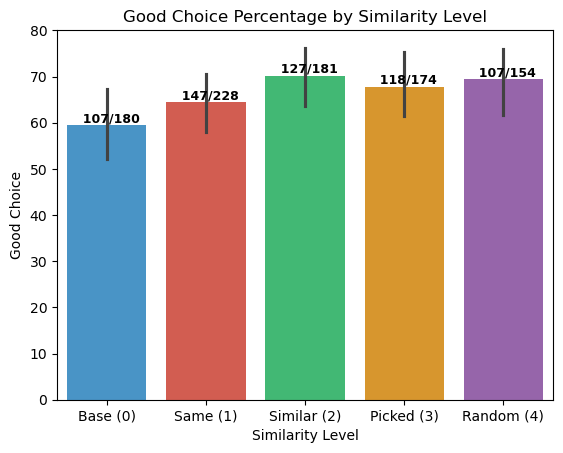

In [ ]:
plot_simple_bar_plot(choice_results, 'similarity_level', 'good_choice', title='Good Choice Percentage by Similarity Level')

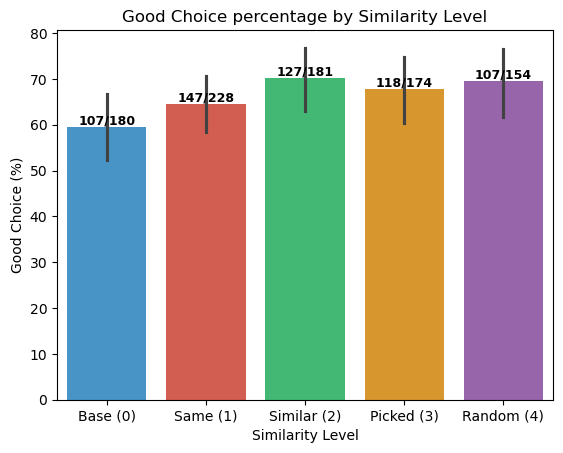

In [ ]:
ax = sns.barplot(
    data=choice_results,
    x='similarity_level',
    y='good_choice',
    estimator=lambda x: np.mean(x) * 100,  # Convert to percentage
    palette=colors_palette
)

# Compute counts per similarity level once
counts = (
    choice_results
    .groupby('similarity_level')['good_choice']
    .agg(total='size', good='sum')
    .reindex(sorted(choice_results['similarity_level'].unique()))
)

# Build labels in the same left-to-right order as bars
levels_in_plot = list(counts.index)
labels = [f"{int(counts.loc[level, 'good'])}/{int(counts.loc[level, 'total'])}" for level in levels_in_plot]

# Annotate all the bars in the plot
for container, label in zip(ax.containers, labels):
    ax.bar_label(container, labels=[label] * len(container), label_type='edge', fontsize=9, fontweight='bold')

plt.xlabel('Similarity Level')
plt.ylabel('Good Choice (%)')
plt.title('Good Choice percentage by Similarity Level')
ax.set_xticklabels(levels_names)

plt.show()

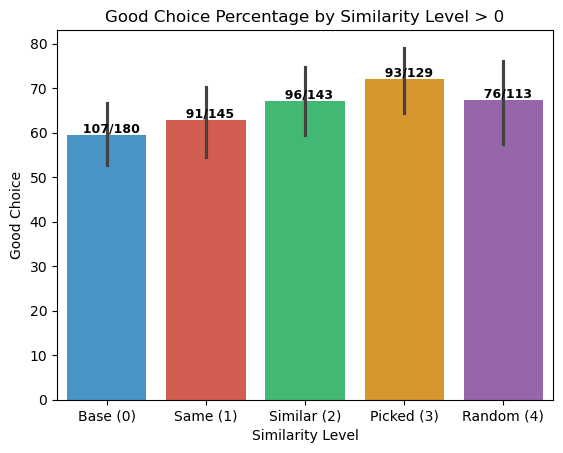

In [ ]:
# only choices that show 1 example
plot_df = choice_results[choice_results['examples_shown'] < 2]
plot_simple_bar_plot(plot_df, 'similarity_level', 'good_choice', title='Good Choice Percentage by Similarity Level > 0')


In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_last_score',
       'update_agent_last_score', 'prev_agent_mean_score',
       'update_agent_mean_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'final_agent', 'final_agent_score'],
      dtype='object')

[['0/14', '6/20', '14/17', '8/18', '5/13'], ['27/27', '28/30', '24/25', '22/26', '23/24']]


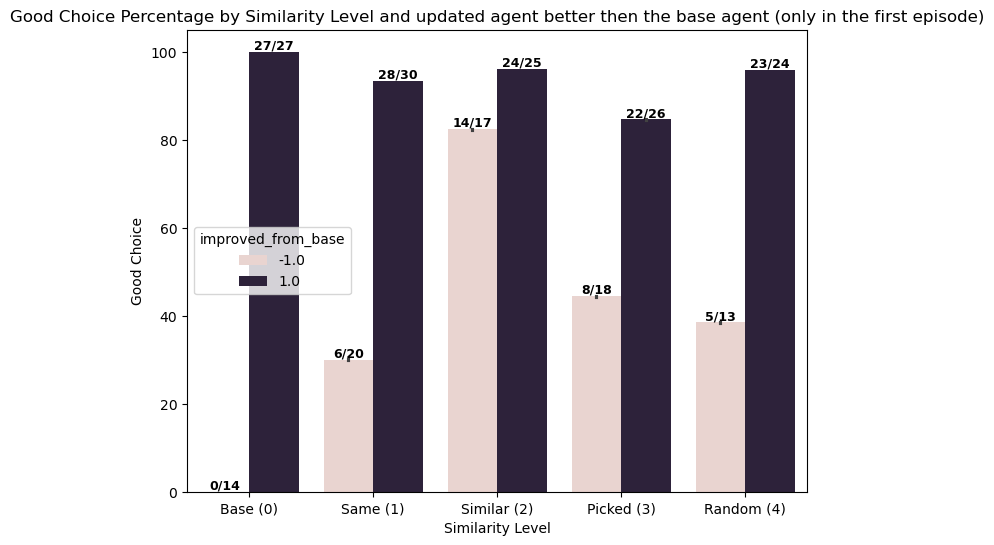

In [ ]:

plot_data = choice_results[choice_results['episode'] == 1].copy()

plot_grouped_barplot(plot_data, 
                     x_col='similarity_level', 
                     y_col='good_choice', 
                     hue='improved_from_base', 
                     title='Good Choice Percentage by Similarity Level and updated agent better then the base agent (only in the first episode)',
                     levels_names=levels_names, 
                     estimator=lambda x: np.mean(x) * 100, 
                     errorbar='se')

In [ ]:
# # Helper: annotate grouped bars with dataset counts per (x, hue)
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# plot_data = choice_results[choice_results['episode'] == 1].copy()

# # Example usage with your current DataFrame and grouping
# hue_col = 'improved_from_base'
# plt.figure(figsize=(8, 6))
# ax = sns.barplot(data=plot_data,
#                   x='similarity_level', y='good_choice',
#                   hue=hue_col, 
#                   estimator=lambda x: np.mean(x) * 100,
#                   errorbar='se')

# hue_values = ax.get_legend_handles_labels()[1]


# # Compute counts per similarity level and hue
# counts = (
#     plot_data
#     .groupby(['similarity_level', hue_col])['good_choice']
#     .agg(total='size', good='sum')
#     .reset_index()
#     .pivot(index='similarity_level', columns=hue_col, values=['total', 'good'])
# )
# print(counts)

# # Build labels in the same left-to-right order as bars
# levels_in_plot = list(counts.index)
# # Build labels as a flat list for each bar in the order they appear
# labels = []
# for improvement in counts['good'].columns:
#     level_labels = []
    
#     for level in levels_in_plot:
#         good = counts['good'].get(improvement, {}).get(level, None)
#         total = counts['total'].get(improvement, {}).get(level, None)
#         # Check for NaN using pandas.isna
#         if not pd.isna(good) and not pd.isna(total):
#             level_labels.append(f"{int(good)}/{int(total)}")

#     labels.append(level_labels)

# print(labels)
# # Annotate all the bars in the plot
# for container, level_labels in zip(ax.containers, labels):
#     print(level_labels)
#     ax.bar_label(container, labels=level_labels, label_type='edge', fontsize=9, fontweight='bold')


# ax.set_xticklabels(levels_names)
# plt.title("User Choices Analysis")
# plt.xlabel("Similarity Level")
# plt.ylabel("Good Choice (%)")

# plt.legend(title=hue_col)
# plt.show()

In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_last_score',
       'update_agent_last_score', 'prev_agent_mean_score',
       'update_agent_mean_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'final_agent', 'final_agent_score'],
      dtype='object')

[['54/95', '99/156', '86/130', '73/105', '85/116'], ['53/85', '48/72', '41/51', '45/69', '22/38']]


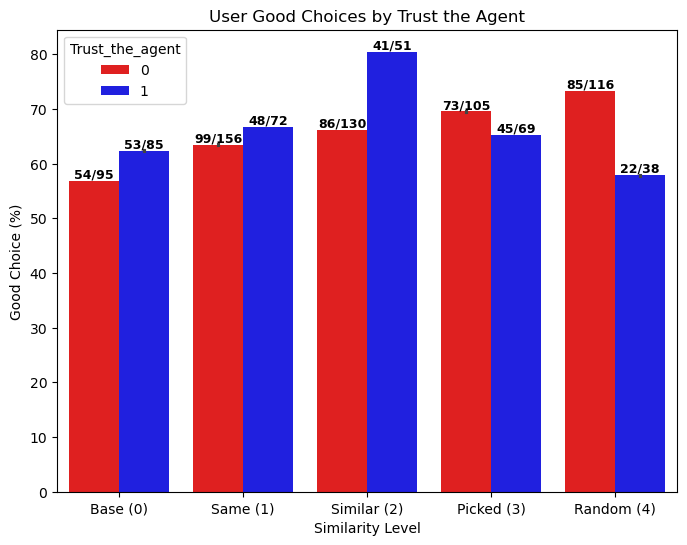

In [ ]:
plot_grouped_barplot(df=choice_results,
                     x_col='similarity_level', 
                     y_col='good_choice',
                     hue='Trust_the_agent',
                     levels_names=levels_names,
                     palette=['red', 'blue'],
                     title="User Good Choices by Trust the Agent",
                     xlabel="Similarity Level",
                     ylabel="Good Choice (%)"
                    )

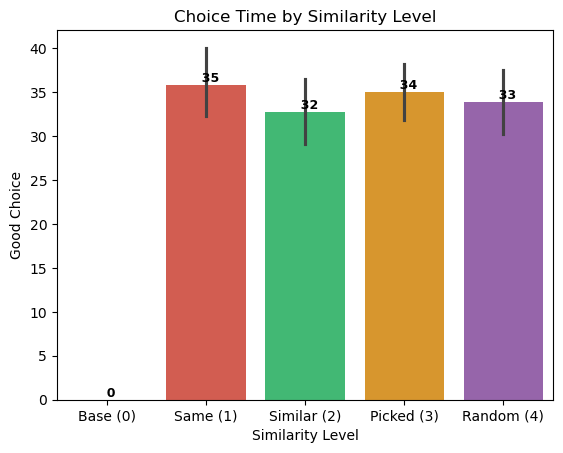

In [ ]:
# choice time by similarity level
plot_simple_bar_plot(choice_results, 'similarity_level', 'choice_time', title='Choice Time by Similarity Level', aggfunc='mean', from_total_agg=False,
    estimator=lambda x: np.mean(x),  # Convert to percentage
    palette=colors_palette,
    errorbar='se'
)

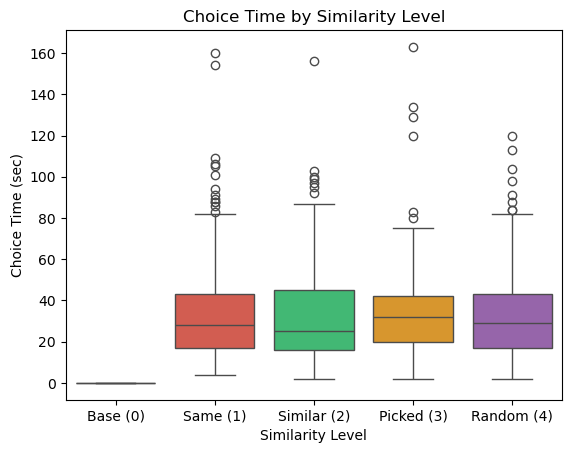

In [ ]:


ax = sns.boxplot(
    data=choice_results[choice_results['choice_time'] < 200], # filter out extreme values
    x='similarity_level',
    y='choice_time',
    palette=colors_palette  # Use the predefined color palette for the box plot
)
plt.xlabel('Similarity Level')
plt.ylabel('Choice Time (sec)')
plt.title('Choice Time by Similarity Level')
ax.set_xticklabels(levels_names)


plt.show()

In [ ]:
user_results.columns

Index(['user_id', 'similarity_level', 'Trust_the_agent', 'number_of_choices',
       'number_of_good_choices', 'number_of_good_choices_last',
       'final_improved', 'final_agent_name'],
      dtype='object')

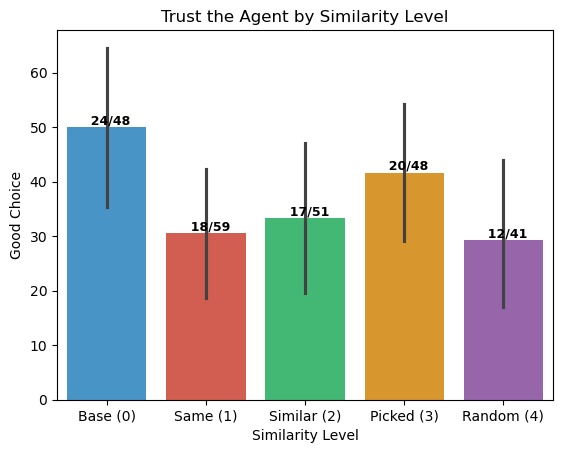

In [ ]:
plot_simple_bar_plot(user_results,
                     'similarity_level',
                     'Trust_the_agent',
                     title='Trust the Agent by Similarity Level',
                     aggfunc='sum',
                     from_total_agg=True,
                     estimator=lambda x: np.mean(x) * 100,
                     palette=colors_palette,
                     errorbar=('ci', 70)
                     )


In [ ]:
user_results.columns

Index(['user_id', 'similarity_level', 'Trust_the_agent', 'number_of_choices',
       'number_of_good_choices', 'number_of_good_choices_last',
       'final_improved', 'final_agent_name'],
      dtype='object')

[['2/5', '1/5', '1/4', '3/5', '2/5'], ['2/3', '0/2', '0/3', '0/4', '2/3'], ['20/40', '17/52', '16/44', '17/39', '8/33']]


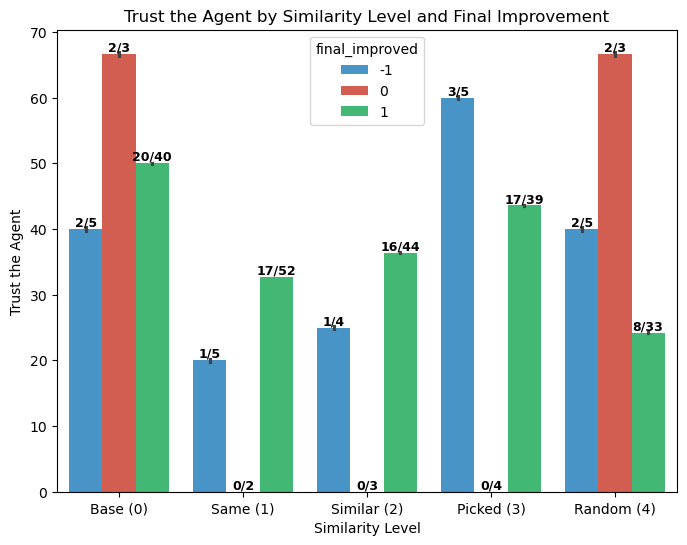

In [ ]:
plot_grouped_barplot(user_results,
                     'similarity_level',
                     'Trust_the_agent',
                     hue='final_improved',
                     estimator=lambda x: np.mean(x) * 100,
                     palette=colors_palette,
                     xlabel='Similarity Level',
                     ylabel='Trust the Agent',
                     title='Trust the Agent by Similarity Level and Final Improvement',
                     levels_names=levels_names,
                     total_indicator=True,
                     )

In [ ]:
user_results.columns

Index(['user_id', 'similarity_level', 'Trust_the_agent', 'number_of_choices',
       'number_of_good_choices', 'number_of_good_choices_last',
       'final_improved', 'final_agent_name'],
      dtype='object')

In [ ]:
tmp_df = user_results[(user_results['final_improved'] == 1) & (user_results['similarity_level'] == 1)]# & (user_results['Trust_the_agent'] == 0)]
tmp_df.count()[0]

52

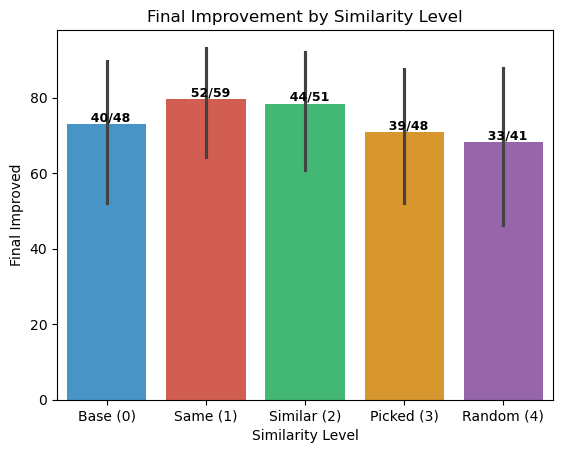

In [ ]:
# improved_from_base but only the last episode
plot_simple_bar_plot(user_results,
                     x_col='similarity_level',
                     y_col='final_improved',
                     y_label='Final Improved',
                     x_label='Similarity Level',
                     title='Final Improvement by Similarity Level',
                     levels_names=levels_names,
                     aggfunc=lambda x: (x == 1).sum(),
                     )

['(,-10)', '[-10,-5)', '[-5,0)', '[0,5)', '[5,10)', '[10,)']
Categories (6, object): ['(,-10)' < '[-10,-5)' < '[-5,0)' < '[0,5)' < '[5,10)' < '[10,)']


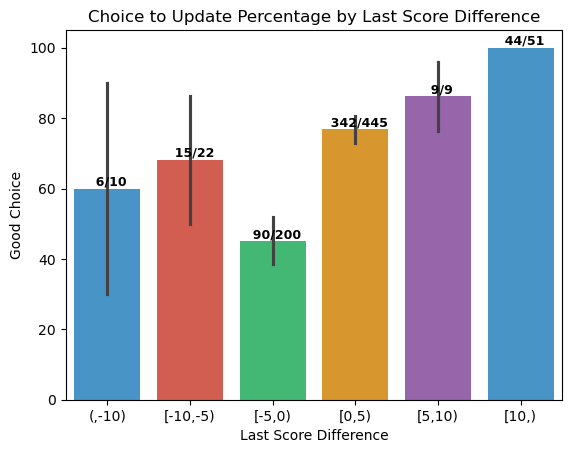

In [ ]:
plot_df = choice_results.copy()
plot_df['last_score_diff'] = round(plot_df['update_agent_last_score'] - plot_df['prev_agent_last_score'], 0)
plot_df['mean_score_diff'] = round(plot_df['update_agent_mean_score'] - plot_df['prev_agent_mean_score'], 0)

# Define bins and labels
bins = [-float('inf'), -10, -5, 0, 5, 10, float('inf')]
labels = ['(,-10)', '[-10,-5)', '[-5,0)', '[0,5)', '[5,10)', '[10,)']

# Apply binning
plot_df['last_score_diff_bin'] = pd.cut(plot_df['last_score_diff'], bins=bins, labels=labels, right=False)

# Filter for similarity_level > 0
plot_df = plot_df[plot_df['similarity_level'] > 0]

# Sort by bins
plot_df = plot_df.sort_values(by='last_score_diff_bin')

print(plot_df['last_score_diff_bin'].unique())

plot_simple_bar_plot(plot_df,
                     x_col='last_score_diff_bin',
                     y_col='choice',
                     title='Choice to Update Percentage by Last Score Difference' ,#'Choice to update percentage by Last Score Difference',
                     estimator=lambda x: np.mean(x) * 100,
                     aggfunc='sum',
                     from_total_agg=True,
                     levels_names=plot_df['last_score_diff_bin'].unique(),
                     x_label='Last Score Difference',
                    #  palette=colors_palette,
                     errorbar='sd'
                     )


['(,-10)', '[-10,-5)', '[-5,0)', '[0,5)', '[5,10)', '[10,)']
Categories (6, object): ['(,-10)' < '[-10,-5)' < '[-5,0)' < '[0,5)' < '[5,10)' < '[10,)']


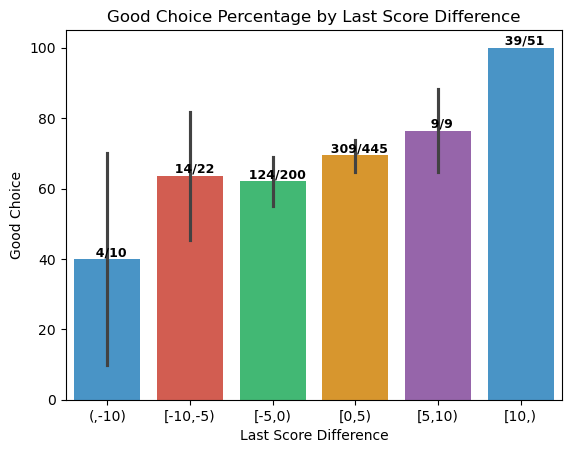

In [ ]:
plot_df = choice_results.copy()
plot_df['last_score_diff'] = round(plot_df['update_agent_last_score'] - plot_df['prev_agent_last_score'], 0)
plot_df['mean_score_diff'] = round(plot_df['update_agent_mean_score'] - plot_df['prev_agent_mean_score'], 0)

# Define bins and labels
bins = [-float('inf'), -10, -5, 0, 5, 10, float('inf')]
labels = ['(,-10)', '[-10,-5)', '[-5,0)', '[0,5)', '[5,10)', '[10,)']

# Apply binning
plot_df['last_score_diff_bin'] = pd.cut(plot_df['last_score_diff'], bins=bins, labels=labels, right=False)

# Filter for similarity_level > 0
plot_df = plot_df[plot_df['similarity_level'] > 0]

# Sort by bins
plot_df = plot_df.sort_values(by='last_score_diff_bin')

print(plot_df['last_score_diff_bin'].unique())

plot_simple_bar_plot(plot_df,
                     x_col='last_score_diff_bin',
                     y_col='good_choice',
                     title='Good Choice Percentage by Last Score Difference' ,#'Choice to update percentage by Last Score Difference',
                     estimator=lambda x: np.mean(x) * 100,
                     aggfunc='sum',
                     from_total_agg=True,
                     levels_names=plot_df['last_score_diff_bin'].unique(),
                     x_label='Last Score Difference',
                    #  y_label='Choice to Update (%)',
                    #  palette=colors_palette,
                     errorbar='sd'
                     )


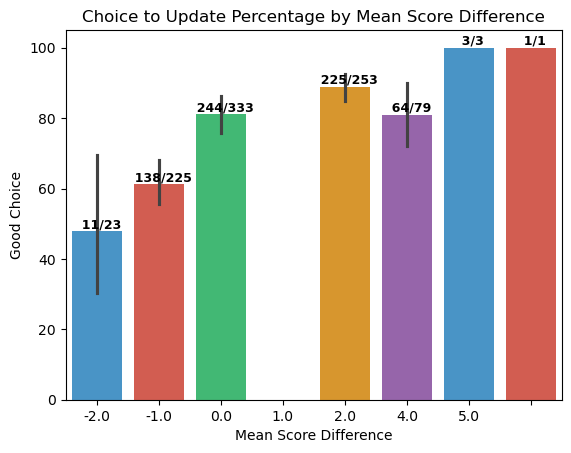

In [864]:
# Mean Score Difference Analysis

plot_df = choice_results.copy()
plot_df['mean_score_diff'] = round(plot_df['update_agent_mean_score'] - plot_df['prev_agent_mean_score'], 0)

plot_df = plot_df.sort_values(by='mean_score_diff')
plot_simple_bar_plot(plot_df,
                     x_col='mean_score_diff',
                     y_col='choice',
                     title='Choice to Update Percentage by Mean Score Difference' ,#'Choice to update percentage by Last Score Difference',
                     estimator=lambda x: np.mean(x) * 100,
                     aggfunc='sum',
                     from_total_agg=True,
                     levels_names=plot_df['mean_score_diff'].unique(),
                     x_label='Mean Score Difference',
                    #  palette=colors_palette,
                     errorbar='sd'
                     )

In [860]:
plot_df['mean_score_diff'].isna().sum()
print(plot_df['mean_score_diff'].unique())

[-2. -1.  0.  1.  2.  4.  5.]


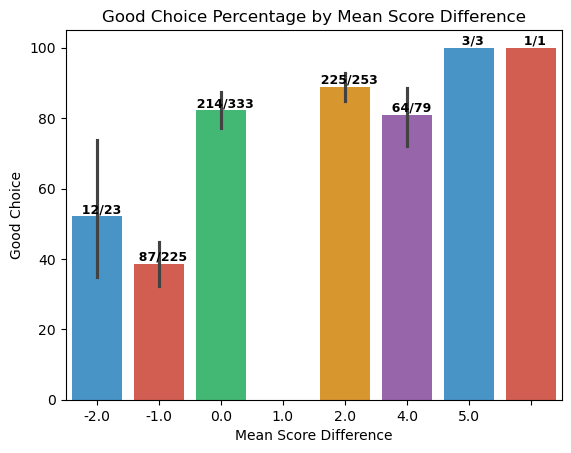

In [ ]:
plot_df = plot_df.sort_values(by='mean_score_diff')
plot_simple_bar_plot(plot_df,
                     x_col='mean_score_diff',
                     y_col='good_choice',
                     title='Good Choice Percentage by Mean Score Difference' ,#'Choice to update percentage by Last Score Difference',
                     estimator=lambda x: np.mean(x) * 100,
                     aggfunc='sum',
                     from_total_agg=True,
                     levels_names=plot_df['mean_score_diff'].unique(),
                     x_label='Mean Score Difference',
                    #  palette=colors_palette,
                     errorbar='sd'
                     )

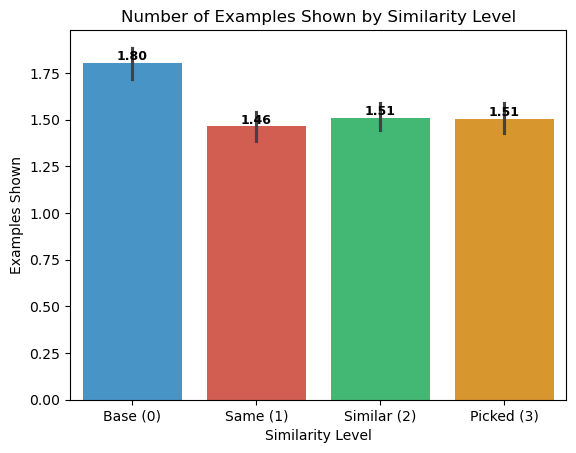

In [ ]:
ax = sns.barplot(
    data=choice_results[choice_results['similarity_level'] > 0],
    x='similarity_level',
    y='examples_shown',
    palette=colors_palette,
    # hue='final_improved',
    estimator= lambda x: np.mean(x),
    errorbar=('ci', 70)
)

for container in ax.containers:
    # Count the number of rows corresponding to each bar
    labels = [f'{bar.get_height():.2f}' for bar in container]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=9, fontweight='bold')

plt.title('Number of Examples Shown by Similarity Level')
plt.xlabel('Similarity Level')
plt.ylabel('Examples Shown')
ax.set_xticklabels(levels_names)
plt.show()